<a href="https://colab.research.google.com/github/Fata-Haidar/244107020108-Pembelajaran-Mesin/blob/main/pertemuan_6/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import library**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

**Membuat Fungsi Konvolusi Manual**

In [3]:
# Konvolusi tanpa Library OpenCV

def convolution2d(image, kernel, stride=1, padding=0):

    # Ukuran kernel
    kernel_h, kernel_w = kernel.shape

    # Menambahkan padding pada citra
    image_padded = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    # Ukuran citra
    image_h, image_w = image_padded.shape

    # Ukuran output
    output_h = (image_h - kernel_h) // stride + 1
    output_w = (image_w - kernel_w) // stride + 1

    # Membuat matriks hasil
    output = np.zeros((output_h, output_w))

    # Proses konvolusi manual
    for y in range(output_h):
        for x in range(output_w):

            region = image_padded[
                y*stride:y*stride+kernel_h,
                x*stride:x*stride+kernel_w
            ]

            output[y, x] = np.sum(region * kernel)

    return output

**Load Gambar dan Mengubah ke Grayscale**

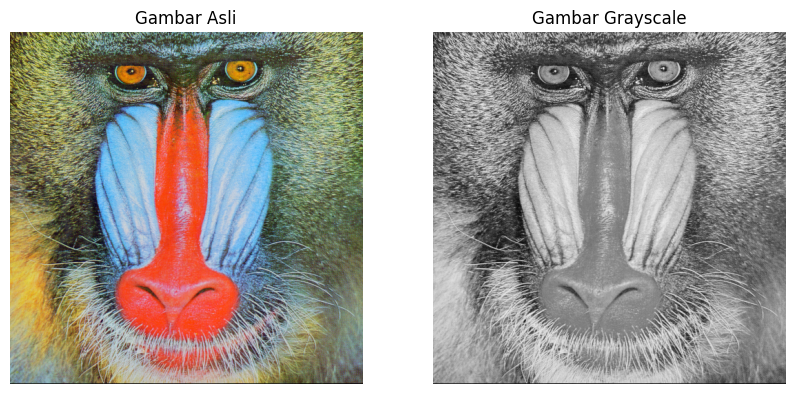

In [4]:
# Load gambar mandrill
BASE = '/content/drive/MyDrive/PCVK'

img = cv.imread(BASE + '/mandrill.tiff')

# Mengubah gambar menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Menampilkan gambar
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Gambar Grayscale')
plt.axis('off')

plt.show()

**Membuat Kernel Sharpening**

In [5]:
# Menentukan kernel Sharpening
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

print("Kernel Sharpening:")
print(kernel_sharpen)

Kernel Sharpening:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


**Menerapkan fungsi konvolusi dan menampilkan hasil Sharpening.**

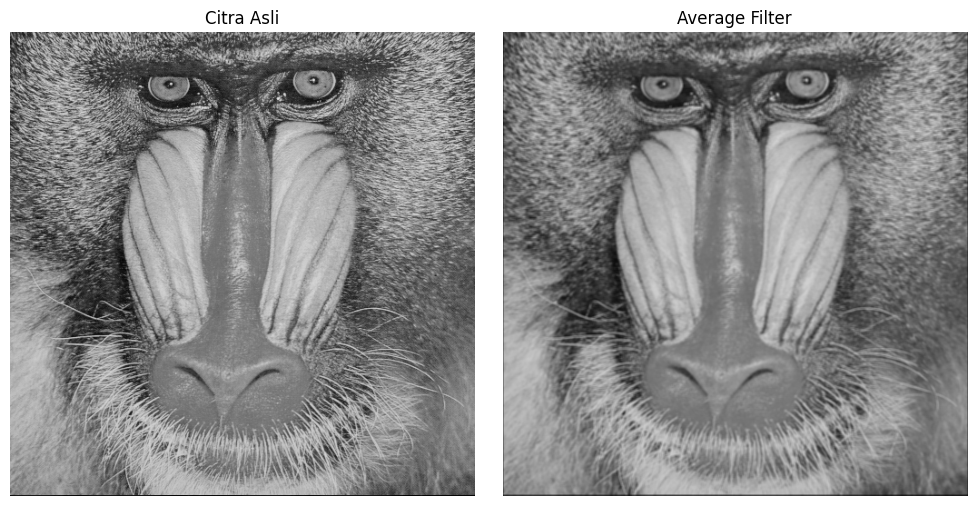

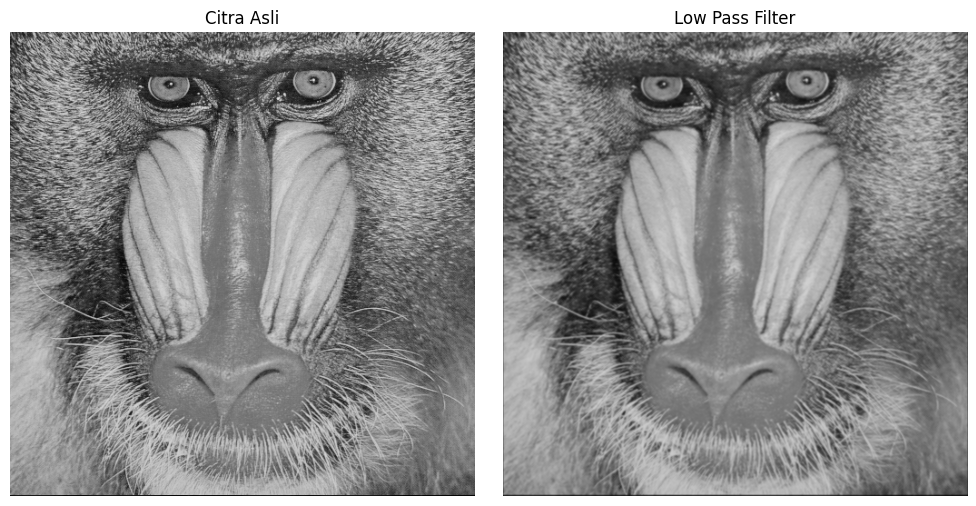

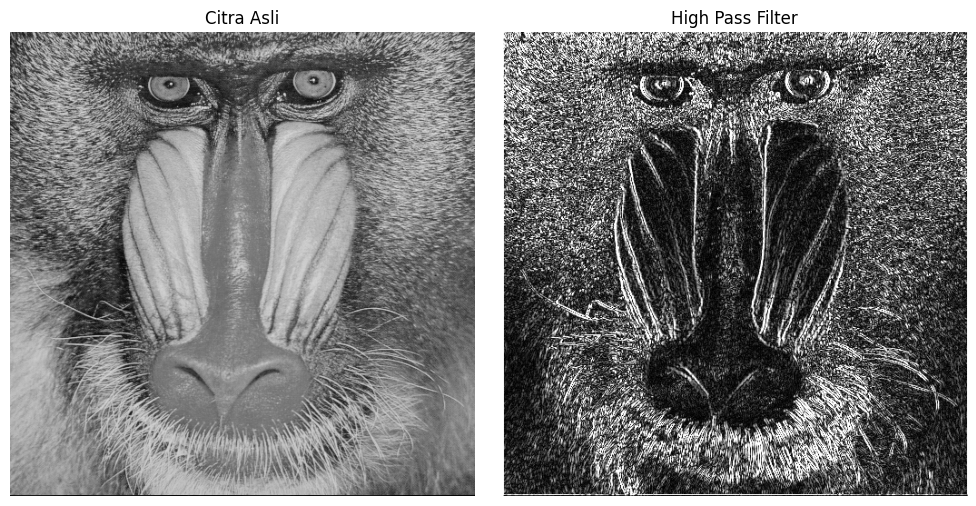

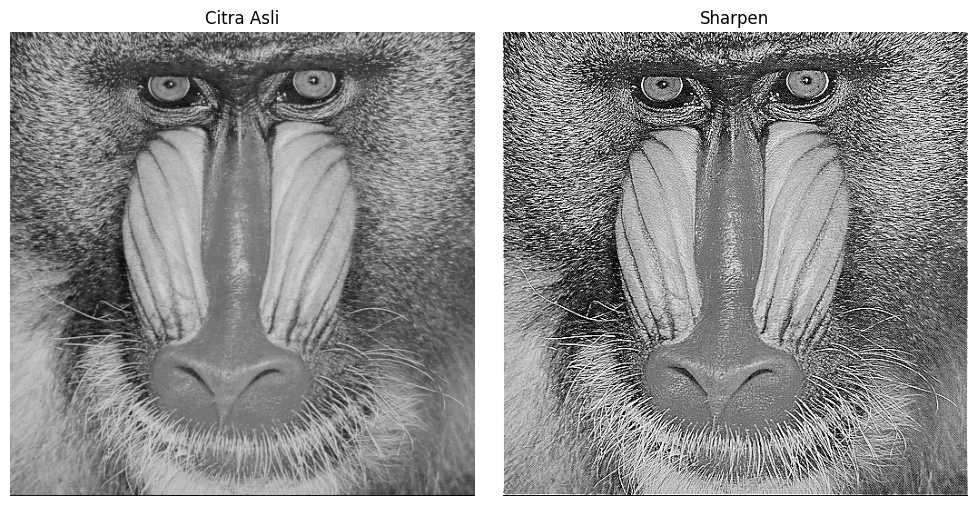

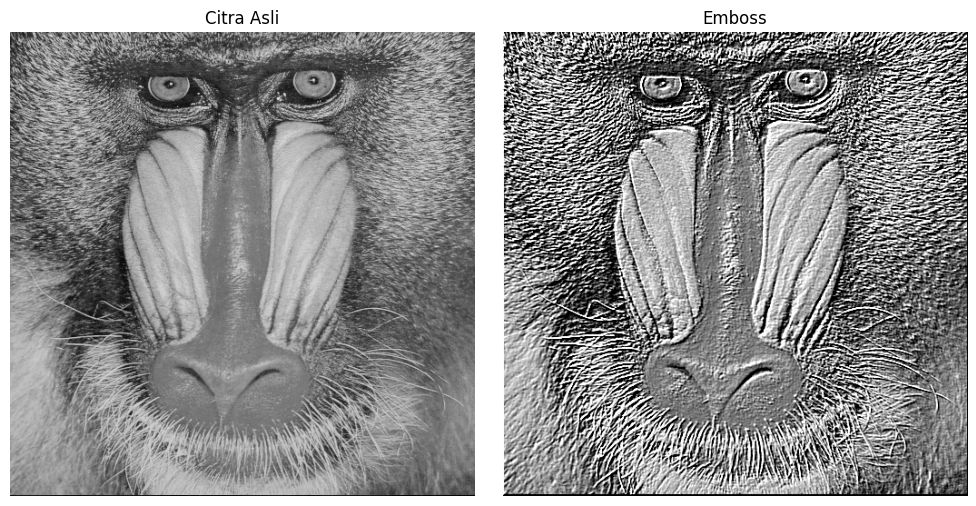

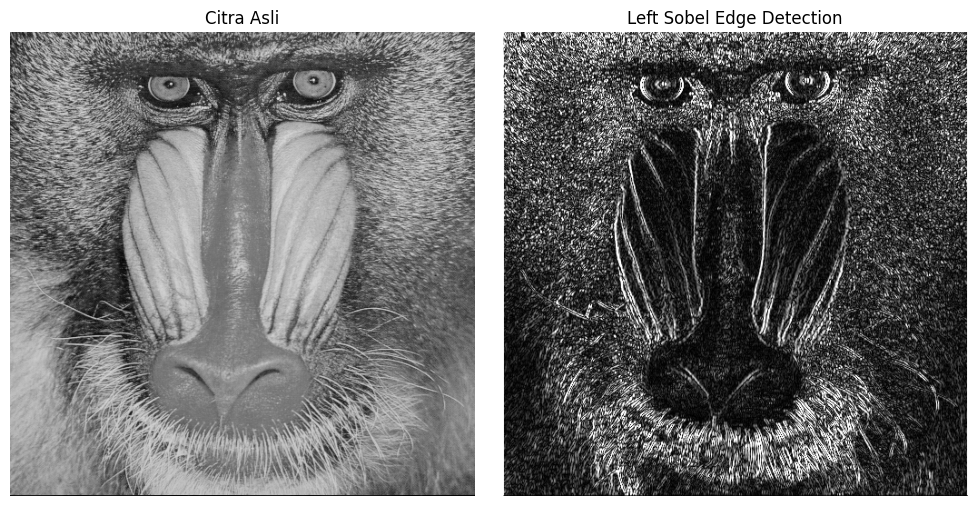

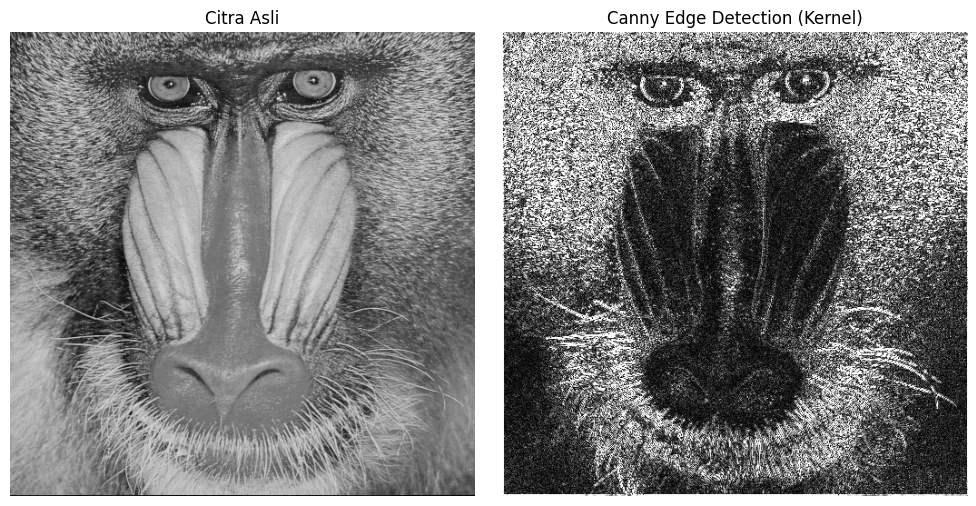

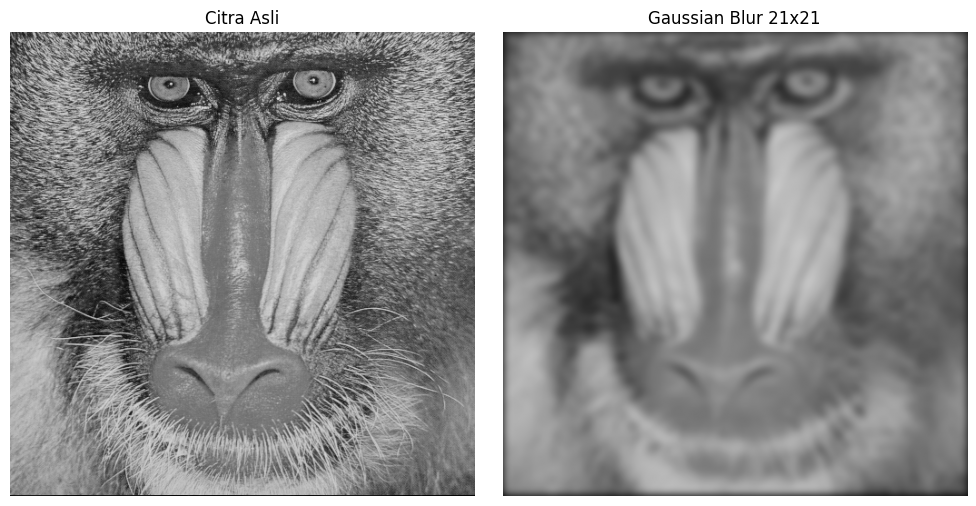

In [8]:
# ==========================================
# PRAKTIKUM 3 - IMAGE FILTER
# ==========================================

# 1. Average Filter
kernel_average = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 9

# 2. Low Pass Filter
kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
]) / 12

# 3. High Pass Filter
kernel_highpass = np.array([
    [-1, 0, 1],
    [-1, 0, 3],
    [-3, 0, 1]
])

# 4. Sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# 5. Emboss
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])

# 6. Left Sobel Edge Detection
kernel_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

# 7. Canny Edge Detection (Kernel sesuai modul)
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# 8. Gaussian Blur 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian = gaussian_kernel @ gaussian_kernel.T


# ==========================================
# MENJALANKAN SEMUA FILTER
# ==========================================

filters = {
    'Average Filter': kernel_average,
    'Low Pass Filter': kernel_lowpass,
    'High Pass Filter': kernel_highpass,
    'Sharpen': kernel_sharpen,
    'Emboss': kernel_emboss,
    'Left Sobel Edge Detection': kernel_sobel,
    'Canny Edge Detection (Kernel)': kernel_canny,
    'Gaussian Blur 21x21': kernel_gaussian
}

hasil_filter = {}

for nama, kernel in filters.items():

    padding = kernel.shape[0] // 2

    # Konvolusi manual
    hasil = convolution2d(
        img_gray,
        kernel,
        stride=1,
        padding=padding
    )

    # Pengaturan hasil masing-masing filter
    if nama == 'Emboss':
        # Tanpa tambahan 128 agar tidak terlalu putih
        hasil = np.clip(hasil, 0, 255)

    elif nama in [
        'High Pass Filter',
        'Left Sobel Edge Detection',
        'Canny Edge Detection (Kernel)'
    ]:
        hasil = np.abs(hasil)
        hasil = np.clip(hasil, 0, 255)

    else:
        hasil = np.clip(hasil, 0, 255)

    hasil = hasil.astype(np.uint8)

    # Menyimpan hasil
    hasil_filter[nama] = hasil

    # Menampilkan gambar
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    plt.title('Citra Asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(hasil, cmap='gray', vmin=0, vmax=255)
    plt.title(nama)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

**FILTER LIBRARY DAN FILTER MODERN**

**Percobaan 1:**

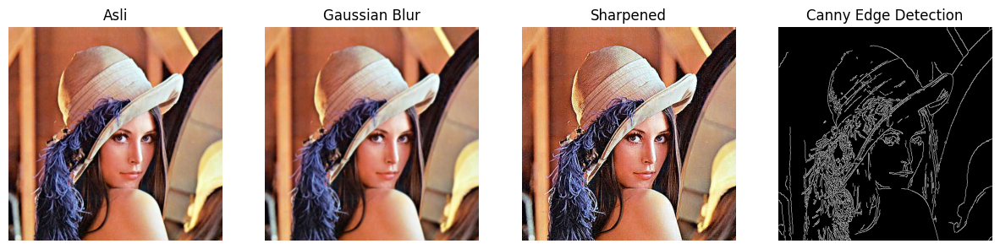

In [9]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()


# Load gambar Lena
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")

if img is None:
    raise FileNotFoundError("Gambar lena.jpg tidak ditemukan!")

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Gaussian Blur
blur = cv.GaussianBlur(img, (7, 7), 1)

# 2. Canny Edge Detection
edges = cv.Canny(
    cv.cvtColor(img, cv.COLOR_BGR2GRAY),
    100, 200
)

# 3. Sharpen
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv.filter2D(img, -1, sharpen_kernel)

# Menampilkan hasil
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

**Percobaan 2 :**

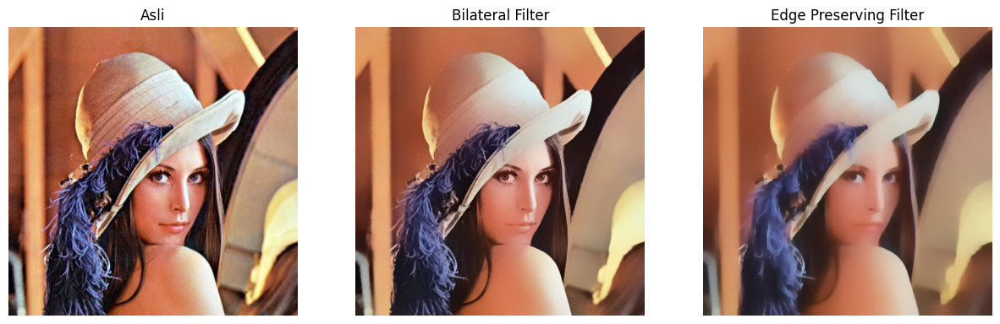

In [10]:
# Filter Modern dari OpenCV

# 1. Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# 2. Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(
    img, flags=1, sigma_s=100, sigma_r=0.9
)

# Menampilkan hasil
show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

**Percobaan 3 :**

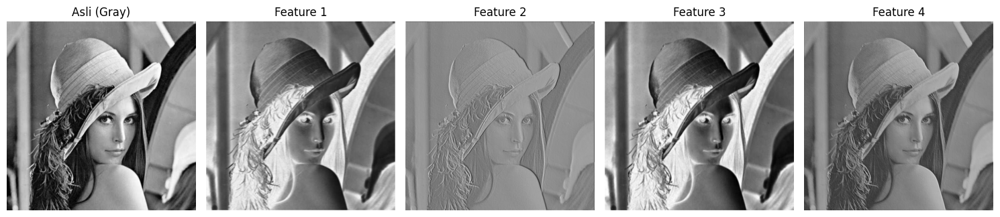

In [65]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Asli (Gray)'] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Percobaan 4 :**

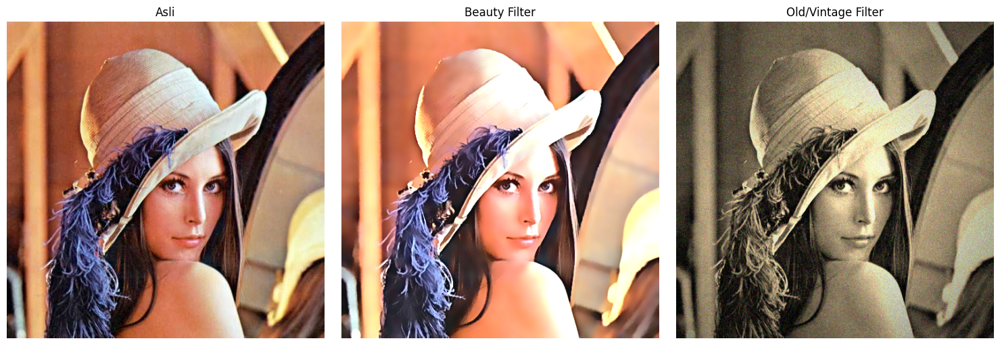

In [66]:
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)

for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

**Percobaan 5 :**

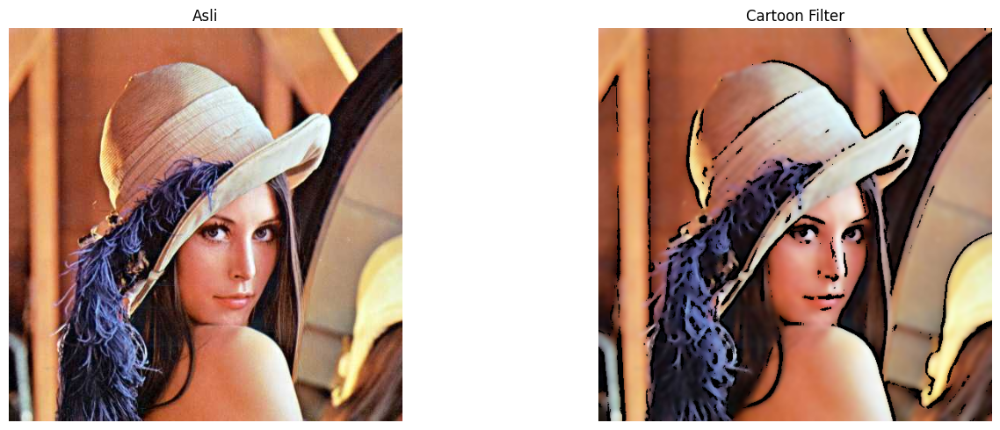

In [68]:
#Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])#Filter Anime / Cartoon

**Percobaan 6 :**

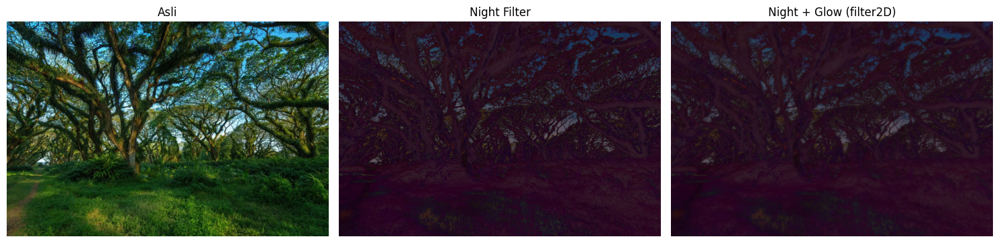

In [70]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")

if img is None:
    raise FileNotFoundError("Gambar djawatan.jpg tidak ditemukan!")

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"]
)

**Percobaan 7:**

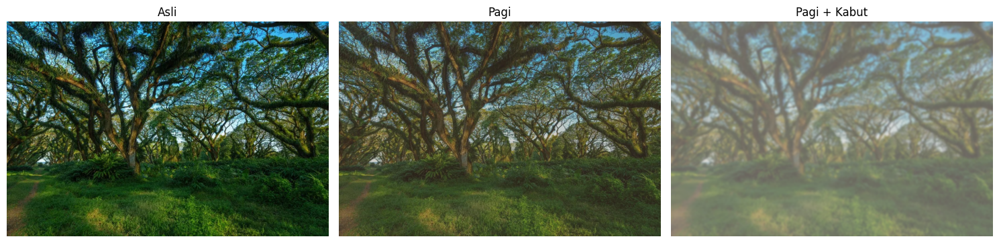

In [71]:
# Filter Suasana pagi dan kabut

# ==============================
# Step 1: Kurangi kontras & cerahkan
# ==============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==============================

# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel1 = cv.getGaussianKernel(13, 3)
kernel = kernel1 @ kernel1.T  # jadikan 2D kernel

kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side(
    [img, pagi, kabut],
    ["Asli", "Pagi", "Pagi + Kabut"]
)

**Tugas 1**

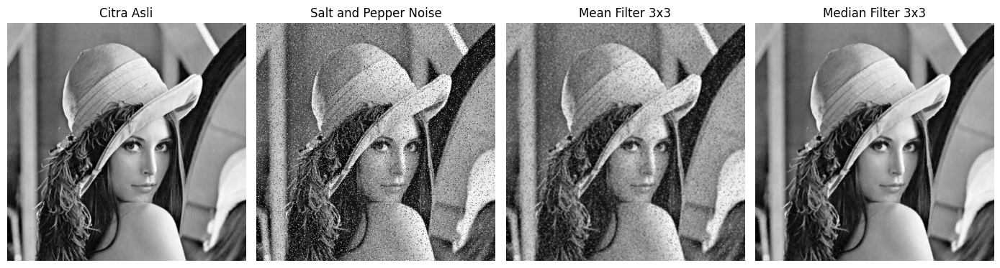

In [72]:
# 1. Load citra Lena dalam grayscale
img_gray = cv.imread(
    '/content/drive/MyDrive/PCVK/lena.jpg',
    cv.IMREAD_GRAYSCALE
)

if img_gray is None:
    raise FileNotFoundError("Gambar lena.jpg tidak ditemukan!")

# 2. Tambahkan Salt and Pepper Noise
np.random.seed(42)

noisy = img_gray.copy()
prob = 0.1

random_noise = np.random.rand(*img_gray.shape)

noisy[random_noise < prob / 2] = 0
noisy[random_noise > 1 - prob / 2] = 255

# 3. Mean Filter 3x3
mean_filter = cv.blur(noisy, (3, 3))

# 4. Median Filter 3x3
median_filter = cv.medianBlur(noisy, 3)

# 5. Menampilkan hasil
plt.figure(figsize=(14, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(noisy, cmap='gray')
plt.title('Salt and Pepper Noise')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mean_filter, cmap='gray')
plt.title('Mean Filter 3x3')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(median_filter, cmap='gray')
plt.title('Median Filter 3x3')
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan**

Mean Filter mengurangi noise dengan menghitung rata-rata piksel, tetapi membuat gambar menjadi lebih buram karena nilai noise ikut memengaruhi rata-rata.

Median Filter lebih efektif menghilangkan noise Salt and Pepper karena mengambil nilai tengah piksel tetangga sehingga bintik hitam-putih dapat dikurangi tanpa banyak menghilangkan detail tepi.

Median Filter 3×3 lebih baik dibandingkan Mean Filter 3×3 untuk menghilangkan noise Salt and Pepper karena menghasilkan citra yang lebih bersih dan tetap mempertahankan detail objek.


**Tugas 2**

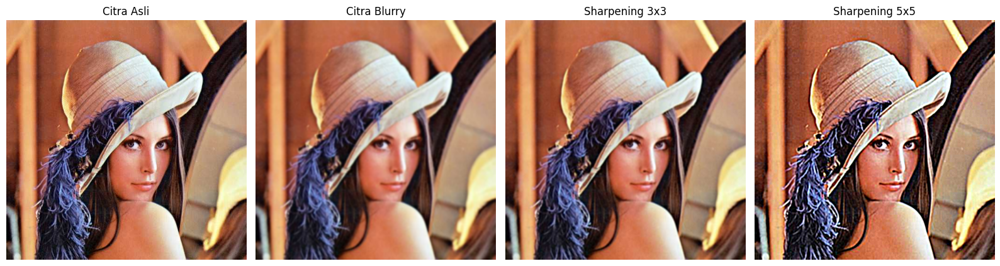

In [73]:
# ==========================================
# TUGAS 2 - SHARPENING KERNEL 3X3 VS 5X5
# ==========================================

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar Lena
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')

if img is None:
    raise FileNotFoundError("Gambar lena.jpg tidak ditemukan!")

# 2. Membuat citra sedikit buram
blurry = cv.GaussianBlur(img, (7, 7), 1.5)

# 3. Kernel Sharpening 3x3
kernel_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# 4. Kernel Sharpening 5x5
kernel_5x5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -1, -1,  0],
    [-1, -1, 13, -1, -1],
    [ 0, -1, -1, -1,  0],
    [ 0,  0, -1,  0,  0]
], dtype=np.float32)

# 5. Menerapkan Sharpening
sharpen_3x3 = cv.filter2D(blurry, -1, kernel_3x3)
sharpen_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

# 6. Menampilkan hasil
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(blurry, cv.COLOR_BGR2RGB))
plt.title('Citra Blurry')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(sharpen_3x3, cv.COLOR_BGR2RGB))
plt.title('Sharpening 3x3')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(cv.cvtColor(sharpen_5x5, cv.COLOR_BGR2RGB))
plt.title('Sharpening 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan**

Kernel Sharpening 3×3 menghasilkan penajaman yang cukup baik dengan memperjelas tepi objek tanpa mengubah detail gambar secara berlebihan. Sementara itu, kernel 5×5 memberikan efek penajaman yang lebih kuat sehingga tepi objek terlihat lebih tegas, tetapi beberapa bagian gambar berpotensi terlihat terlalu tajam.

Kadar Noise/Noise Distortion: Kernel 3×3 cenderung menghasilkan noise dan distorsi yang lebih rendah karena proses penajamannya lebih ringan. Sebaliknya, kernel 5×5 pada percobaan ini berpotensi memperkuat noise dan menimbulkan distorsi pada area yang memiliki banyak detail, sehingga hasil gambar dapat terlihat kurang alami.

Kernel Sharpening 3×3 lebih optimal untuk penggunaan sehari-hari karena memberikan keseimbangan antara kejelasan tepi dan tingkat noise yang rendah. Kernel 5×5 lebih cocok digunakan ketika membutuhkan penajaman yang lebih kuat, tetapi perlu memperhatikan risiko distorsi yang dihasilkan.

**Tugas 3**

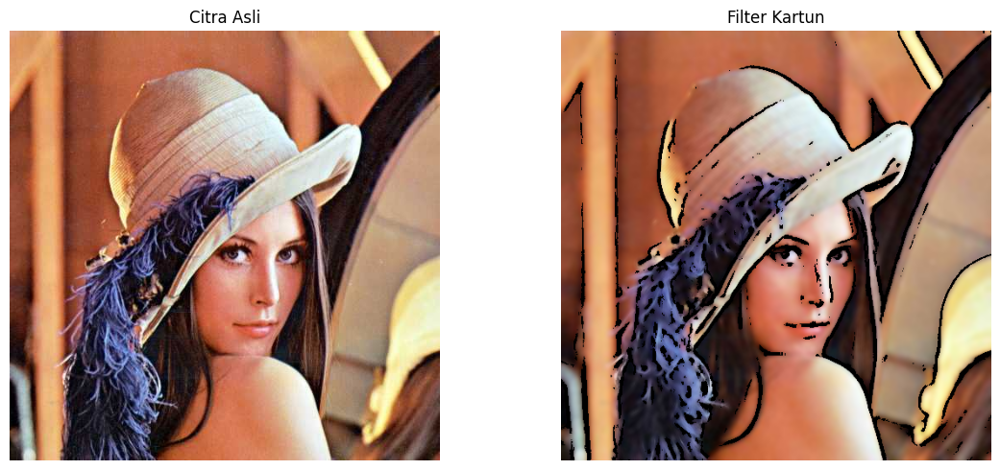

In [74]:
# 1. Load gambar Lena
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')

if img is None:
    raise FileNotFoundError("Gambar lena.jpg tidak ditemukan!")

# 2. Membuat fungsi kartun
def kartun(image):

    # Bilateral Filter untuk menghaluskan warna
    smooth = cv.bilateralFilter(
        image, 9, 200, 200
    )

    # Mengubah gambar menjadi grayscale
    gray = cv.cvtColor(
        image, cv.COLOR_BGR2GRAY
    )

    # Median Blur untuk mengurangi noise
    gray_blur = cv.medianBlur(gray, 7)

    # Adaptive Thresholding untuk deteksi tepi
    edges = cv.adaptiveThreshold(
        gray_blur,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        9,
        9
    )

    # Menggabungkan warna dan tepi
    cartoon = cv.bitwise_and(
        smooth, smooth, mask=edges
    )

    return cartoon


# 3. Menerapkan fungsi kartun
hasil_kartun = kartun(img)

# 4. Menampilkan hasil berdampingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_kartun, cv.COLOR_BGR2RGB))
plt.title('Filter Kartun')
plt.axis('off')

plt.tight_layout()
plt.show()